# ANN from scratch: a 2-layer MLP solving XOR

Companion to `notes.md`'s "From-scratch implementation" section. We hand-derive and
implement, in plain NumPy, the smallest network that can do something a single linear
layer provably cannot: forward propagation through one hidden layer, manual backward
propagation via the chain rule, and a gradient-descent weight update — trained on the
XOR dataset.

No Keras, no autograd — every gradient below is written out by hand so the chain rule
derivation in `notes.md` maps 1:1 onto code.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
np.set_printoptions(precision=4, suppress=True)

## The XOR dataset

Four points, two classes, arranged so that no single straight line can separate them:
the two "positive" points sit on opposite corners of the unit square from the two
"negative" points.

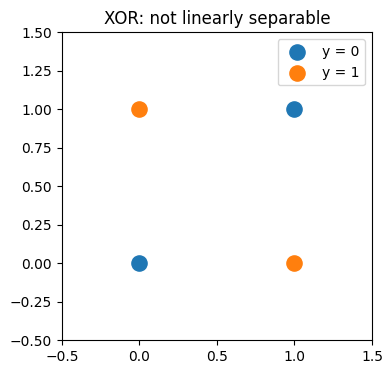

In [2]:
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1],
], dtype=float)
y = np.array([0, 1, 1, 0], dtype=float).reshape(-1, 1)  # XOR

plt.figure(figsize=(4, 4))
plt.scatter(X[y[:, 0] == 0, 0], X[y[:, 0] == 0, 1], color="tab:blue", s=120, label="y = 0")
plt.scatter(X[y[:, 0] == 1, 0], X[y[:, 0] == 1, 1], color="tab:orange", s=120, label="y = 1")
plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)
plt.legend()
plt.title("XOR: not linearly separable")
plt.show()

## Proof a single linear layer cannot solve this

A single-layer model (perceptron / logistic regression, per `notes.md`'s "Why simpler
approaches fail") predicts via one hyperplane $\hat y = \sigma(w^Tx + b)$. Fit one with
plain gradient descent directly on XOR and check the accuracy it converges to — it
should get stuck at 50% (chance level for 4 points, 2 per class), because there is
genuinely no straight line in this 2D square that puts both `y=1` corners on one side
and both `y=0` corners on the other.

In [3]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

# Single linear layer: z = w^T x + b, yhat = sigmoid(z)
w = np.zeros((2, 1))
b = 0.0
lr = 0.5

for epoch in range(5000):
    z = X @ w + b
    yhat = sigmoid(z)
    error = yhat - y
    grad_w = X.T @ error / len(X)
    grad_b = np.mean(error)
    w -= lr * grad_w
    b -= lr * grad_b

single_layer_preds = (sigmoid(X @ w + b) > 0.5).astype(float)
single_layer_acc = (single_layer_preds == y).mean()
print("Single linear layer predictions:", single_layer_preds.ravel())
print("Single linear layer accuracy on XOR:", single_layer_acc)
assert single_layer_acc <= 0.75, "a single linear layer should NOT solve XOR"


Single linear layer predictions: [0. 0. 0. 0.]
Single linear layer accuracy on XOR: 0.5


## The 2-layer MLP

Two inputs $\to$ a hidden layer of a few neurons with a non-linear activation $\to$ one
sigmoid output neuron. The non-linearity in the hidden layer is exactly what lets this
network bend a straight decision boundary into something that can wrap around the XOR
pattern (per the Universal Approximation Theorem discussion in `notes.md`).

$$z^{[1]} = XW^{[1]} + b^{[1]}, \qquad a^{[1]} = \tanh(z^{[1]})$$
$$z^{[2]} = a^{[1]}W^{[2]} + b^{[2]}, \qquad \hat y = a^{[2]} = \sigma(z^{[2]})$$

Weights are initialized small and random (not zero — zero-init would make every hidden
unit compute the same thing and receive the same gradient, the "symmetry problem" from
`notes.md`'s Weight Initialisation section).

In [4]:
n_input, n_hidden, n_output = 2, 4, 1

W1 = np.random.randn(n_input, n_hidden) * 0.5
b1 = np.zeros((1, n_hidden))
W2 = np.random.randn(n_hidden, n_output) * 0.5
b2 = np.zeros((1, n_output))

def forward(X, W1, b1, W2, b2):
    z1 = X @ W1 + b1
    a1 = np.tanh(z1)
    z2 = a1 @ W2 + b2
    a2 = sigmoid(z2)
    cache = (z1, a1, z2, a2)
    return a2, cache

yhat, cache = forward(X, W1, b1, W2, b2)
print("Initial (untrained) predictions:\n", yhat)

Initial (untrained) predictions:
 [[0.5   ]
 [0.4616]
 [0.6511]
 [0.6258]]


## Loss: binary cross-entropy

Same loss as `notes.md`'s "Regression & Classification Loss Functions" section:

$$L = -\frac{1}{m}\sum_{i=1}^{m}\left[y_i\log(\hat y_i) + (1-y_i)\log(1-\hat y_i)\right]$$

In [5]:
def bce_loss(y, yhat):
    eps = 1e-9  # avoid log(0)
    return -np.mean(y * np.log(yhat + eps) + (1 - y) * np.log(1 - yhat + eps))

print("Initial loss:", bce_loss(y, yhat))

Initial loss: 0.7195357237154479


## Manual backward pass: the chain rule, one hidden layer deep

This is the `notes.md` backprop derivation applied to this exact 2-layer network.
Define the output-layer error signal first, then chain it back through $W^{[2]}$ into
the hidden layer:

$$\delta^{[2]} = \hat y - y \quad \text{(BCE + sigmoid output combine to this simple form)}$$
$$\frac{\partial L}{\partial W^{[2]}} = (a^{[1]})^T \delta^{[2]}, \qquad \frac{\partial L}{\partial b^{[2]}} = \sum \delta^{[2]}$$
$$\delta^{[1]} = \left(\delta^{[2]} (W^{[2]})^T\right) \odot \tanh'(z^{[1]}), \qquad \tanh'(z) = 1 - \tanh^2(z)$$
$$\frac{\partial L}{\partial W^{[1]}} = X^T \delta^{[1]}, \qquad \frac{\partial L}{\partial b^{[1]}} = \sum \delta^{[1]}$$

Every line here is a direct instance of `notes.md`'s general
$\boldsymbol{\delta}^{[l]} = \left((\mathbf{W}^{[l+1]})^T\boldsymbol{\delta}^{[l+1]}\right)\odot g'^{[l]}(\mathbf{z}^{[l]})$
recursion, specialized to $L=2$ layers.

In [6]:
def backward(X, y, cache, W1, W2):
    m = X.shape[0]
    z1, a1, z2, a2 = cache

    delta2 = a2 - y                              # (m, 1)
    dW2 = a1.T @ delta2 / m                       # (n_hidden, 1)
    db2 = np.sum(delta2, axis=0, keepdims=True) / m

    dtanh = 1 - np.tanh(z1) ** 2                  # tanh'(z1)
    delta1 = (delta2 @ W2.T) * dtanh              # (m, n_hidden)
    dW1 = X.T @ delta1 / m                        # (n_input, n_hidden)
    db1 = np.sum(delta1, axis=0, keepdims=True) / m

    return dW1, db1, dW2, db2

## Gradient descent training loop

Plain full-batch gradient descent, $\theta \leftarrow \theta - \eta \nabla L(\theta)$, on
all four XOR points at once.

In [7]:
lr = 0.5
n_epochs = 10000
loss_history = []

for epoch in range(n_epochs):
    yhat, cache = forward(X, W1, b1, W2, b2)
    loss = bce_loss(y, yhat)
    loss_history.append(loss)

    dW1, db1, dW2, db2 = backward(X, y, cache, W1, W2)

    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2

    if epoch % 2000 == 0:
        print(f"epoch {epoch:5d}  loss {loss:.4f}")

final_preds, _ = forward(X, W1, b1, W2, b2)
final_acc = ((final_preds > 0.5).astype(float) == y).mean()
print("\nFinal predictions:\n", final_preds)
print("Final accuracy:", final_acc)
assert final_acc == 1.0, "the 2-layer MLP should solve XOR perfectly"


epoch     0  loss 0.7195
epoch  2000  loss 0.0023
epoch  4000  loss 0.0011
epoch  6000  loss 0.0007
epoch  8000  loss 0.0005



Final predictions:
 [[0.0004]
 [0.9994]
 [0.9999]
 [0.0006]]
Final accuracy: 1.0


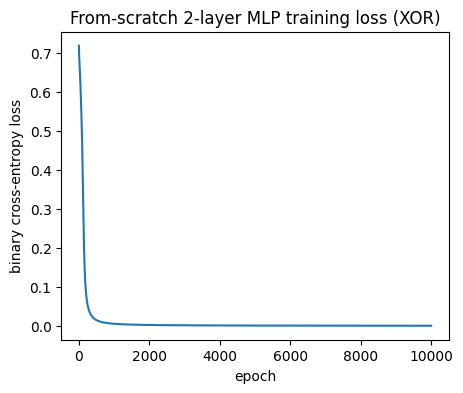

In [8]:
plt.figure(figsize=(5, 4))
plt.plot(loss_history)
plt.xlabel("epoch")
plt.ylabel("binary cross-entropy loss")
plt.title("From-scratch 2-layer MLP training loss (XOR)")
plt.show()

## Decision boundary

Unlike the single linear layer above (one straight line, stuck at 50% accuracy), the
trained 2-layer MLP's decision boundary bends around the XOR pattern.

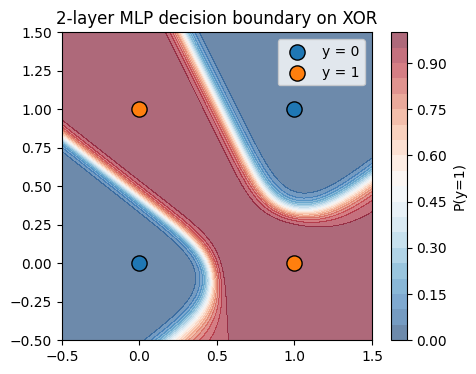

In [9]:
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
probs, _ = forward(grid, W1, b1, W2, b2)
probs = probs.reshape(xx.shape)

plt.figure(figsize=(5, 4))
plt.contourf(xx, yy, probs, levels=20, cmap="RdBu_r", alpha=0.6)
plt.colorbar(label="P(y=1)")
plt.scatter(X[y[:, 0] == 0, 0], X[y[:, 0] == 0, 1], color="tab:blue", edgecolor="k", s=120, label="y = 0")
plt.scatter(X[y[:, 0] == 1, 0], X[y[:, 0] == 1, 1], color="tab:orange", edgecolor="k", s=120, label="y = 1")
plt.legend()
plt.title("2-layer MLP decision boundary on XOR")
plt.show()

## Takeaway

The single linear layer (`w^Tx + b`) converges to ~50% accuracy on XOR no matter how
long it trains, because no straight line separates the classes. Adding one hidden
layer with a non-linear activation — and deriving its gradients by hand via the exact
chain-rule recursion in `notes.md` — solves it perfectly. This is the smallest possible
demonstration of why depth + non-linearity, not just more linear capacity, is what
neural networks add over `05-machine-learning`'s linear models.